### 기본  설정 세팅

In [40]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

---
## Part A. Hand Calculation + NumPy Verification



### 모델 구조
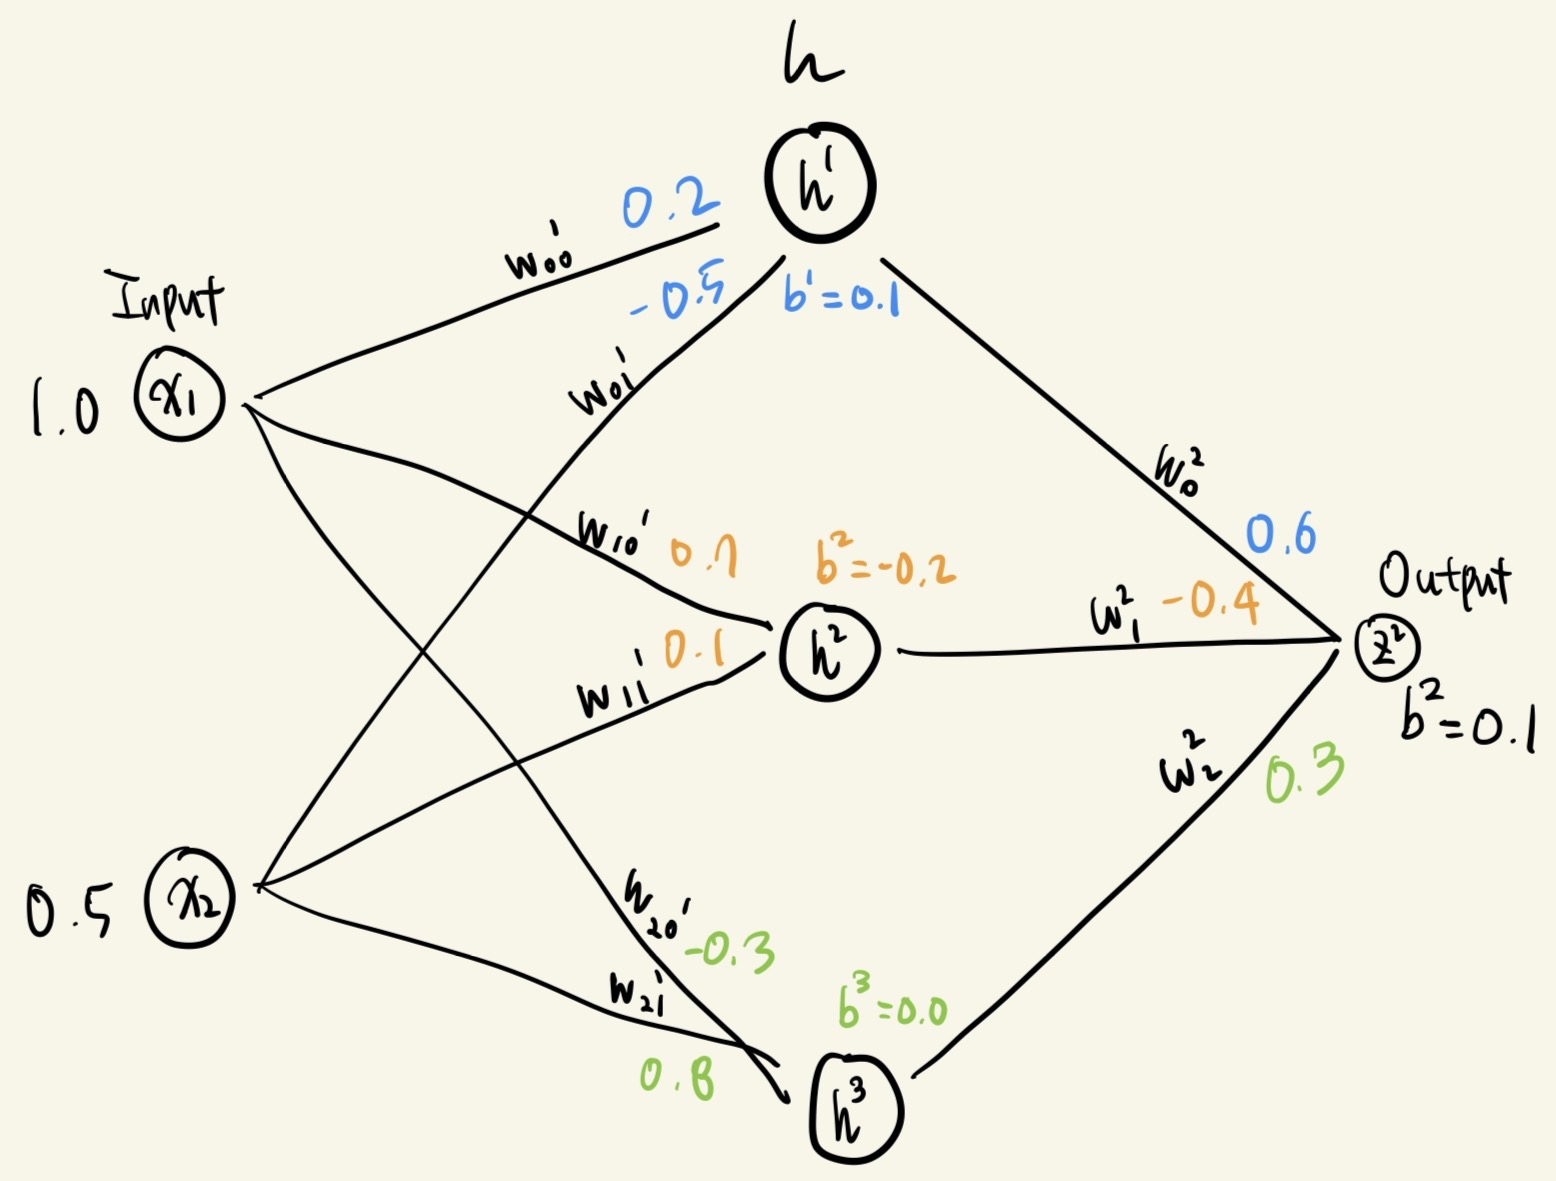

### A1. Forward Pass

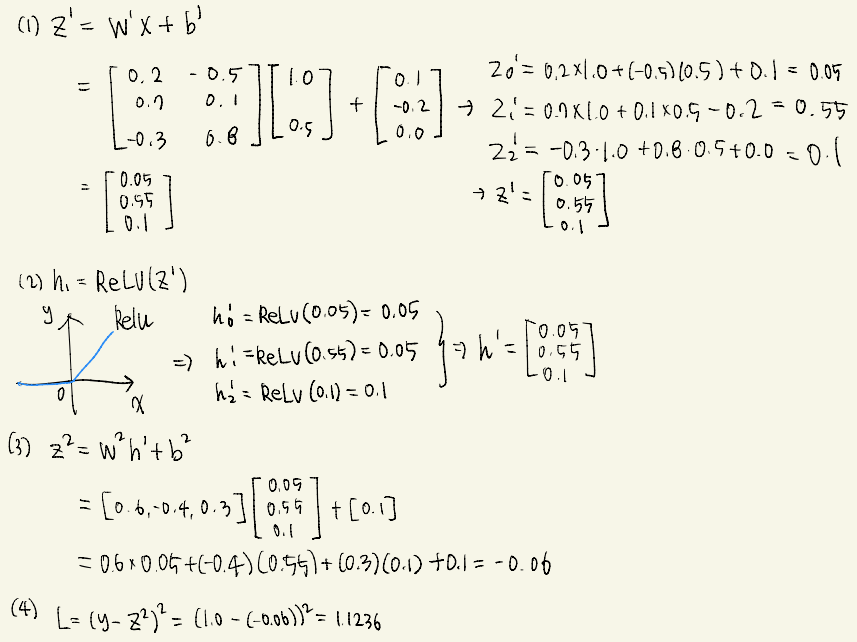

### A2. Backward Pass
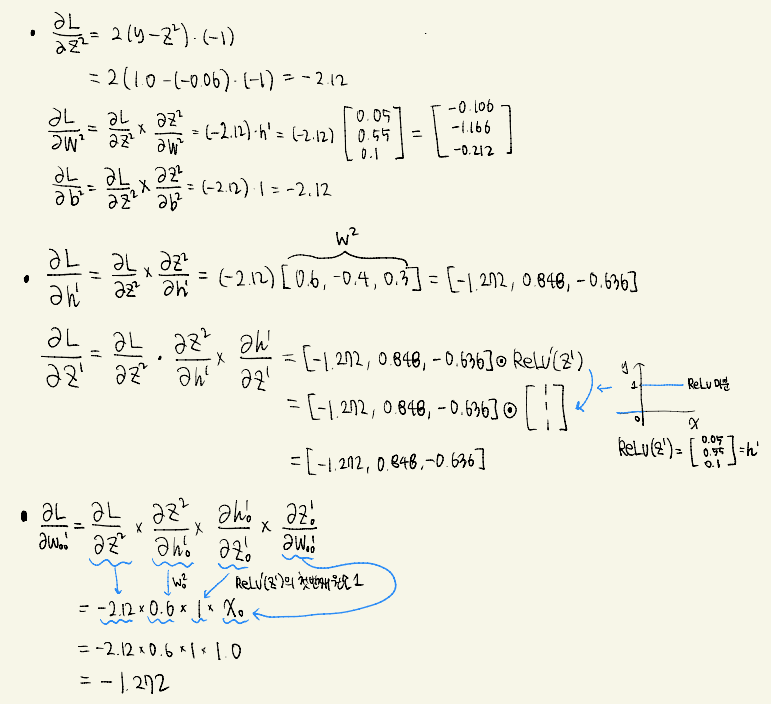

### A3. NumPy Verification

In [41]:
# A3: NumPy Verification
set_seed(42)

# weight 초기화
W1 = np.array([[0.2, -0.5],
               [0.7,  0.1],
               [-0.3, 0.8]])
b1 = np.array([0.1, -0.2, 0.0])
W2 = np.array([[0.6, -0.4, 0.3]])
b2 = np.array([0.1])
x  = np.array([1.0, 0.5])
y  = 1.0

# Forward Pass
z1 = W1 @ x + b1 #행렬 곱 적용

# activation 함수로 ReLu 사용
def ReLu(x):
    return np.maximum(0, x)
h1 = ReLu(z1)

z2 = W2 @ h1 + b2

L = (y - z2)**2

# Backward Pass
dL_dz2 = -2 * (y - z2)

dz2_dw2 = h1

dL_dW2 = dL_dz2 * dz2_dw2

dz2_db2 = 1

dL_db2 = dL_dz2 * dz2_db2

dz2_dh1 = W2

dL_dh1 = dL_dz2 * dz2_dh1

dh1_dz1 = (z1 > 0).astype(float) #ReLu함수 미분 값

dL_dz1 = dL_dz2 * dz2_dh1 * dh1_dz1

dz2_dh10 = W2[0][0]

dh10_dz10 = dh1_dz1[0]

dz10_dw100 = x[0]

dL_dw00 = dL_dz2 * dz2_dh10 * dh10_dz10 * dz10_dw100

print("--Forward Pass--")
print(f"z1 = W1 @ x + b1 = {z1}")
print(f"h1 = ReLU(z1) = {h1}")
print(f"z2 = W2 @ h1 + b2 = {z2}")
print(f"L  = (y - z2)^2  = {L}")

print("\n--Backward Pass--")
print(f"dL/dz2 = {dL_dz2}")
print(f"dL/dW2 = {dL_dW2}")
print(f"dL/db2 = {dL_db2}")
print(f"dL/dh1 = {dL_dh1}")
print(f"ReLU 미분 값 = {dh1_dz1}")
print(f"dL/dz1 = {dL_dz1}")
print(f"dL/dw00^1 = {dL_dw00}")

print("\n--손으로 계산한 것과 NumPy 결과값 비교--")
print(f"z1       : NumPy={z1}, Hand=[0.05, 0.55, 0.10]")
print(f"h1       : NumPy={h1}, Hand=[0.05, 0.55, 0.10]")
print(f"z2       : NumPy={z2}, Hand=-0.06")
print(f"L        : NumPy={L}, Hand=1.1236")
print(f"dL/dz2   : NumPy={dL_dz2}, Hand=-2.12")
print(f"dL/dW2   : NumPy={dL_dW2}, Hand=[-0.106, -1.166, -0.212]")
print(f"dL/db2   : NumPy={dL_db2}, Hand=-2.12")
print(f"dL/dh1   : NumPy={dL_dh1}, Hand=[-1.272, 0.848, -0.636]")
print(f"dL/dz1   : NumPy={dL_dz1}, Hand=[-1.272, 0.848, -0.636]")
print(f"dL/dw00^1: NumPy={dL_dw00}, Hand=-1.2720")

print("\n => 두 결과가 완전히 똑같다")

--Forward Pass--
z1 = W1 @ x + b1 = [0.05 0.55 0.1 ]
h1 = ReLU(z1) = [0.05 0.55 0.1 ]
z2 = W2 @ h1 + b2 = [-0.06]
L  = (y - z2)^2  = [1.1236]

--Backward Pass--
dL/dz2 = [-2.12]
dL/dW2 = [-0.106 -1.166 -0.212]
dL/db2 = [-2.12]
dL/dh1 = [[-1.272  0.848 -0.636]]
ReLU 미분 값 = [1. 1. 1.]
dL/dz1 = [[-1.272  0.848 -0.636]]
dL/dw00^1 = [-1.272]

--손으로 계산한 것과 NumPy 결과값 비교--
z1       : NumPy=[0.05 0.55 0.1 ], Hand=[0.05, 0.55, 0.10]
h1       : NumPy=[0.05 0.55 0.1 ], Hand=[0.05, 0.55, 0.10]
z2       : NumPy=[-0.06], Hand=-0.06
L        : NumPy=[1.1236], Hand=1.1236
dL/dz2   : NumPy=[-2.12], Hand=-2.12
dL/dW2   : NumPy=[-0.106 -1.166 -0.212], Hand=[-0.106, -1.166, -0.212]
dL/db2   : NumPy=[-2.12], Hand=-2.12
dL/dh1   : NumPy=[[-1.272  0.848 -0.636]], Hand=[-1.272, 0.848, -0.636]
dL/dz1   : NumPy=[[-1.272  0.848 -0.636]], Hand=[-1.272, 0.848, -0.636]
dL/dw00^1: NumPy=[-1.272], Hand=-1.2720

 => 두 결과가 완전히 똑같다


**결론:** 모든 NumPy 결과값은 손으로 계산한 것과 같다. Numpy를 이용한 chain rule 연산과 손으로 계산한 chain rule 연산이 모두 정확하다.

---
## Part B. PyTorch MLP: Implementation & Experiments

### B1. Baseline Implementation

Total: 1000, Train: 700, Val: 300
Epoch [20/200], Train Loss: 0.2851, Val Loss: 0.2839
Epoch [40/200], Train Loss: 0.2583, Val Loss: 0.2638
Epoch [60/200], Train Loss: 0.2365, Val Loss: 0.2449
Epoch [80/200], Train Loss: 0.2120, Val Loss: 0.2242
Epoch [100/200], Train Loss: 0.1931, Val Loss: 0.2083
Epoch [120/200], Train Loss: 0.1797, Val Loss: 0.1972
Epoch [140/200], Train Loss: 0.1686, Val Loss: 0.1881
Epoch [160/200], Train Loss: 0.1607, Val Loss: 0.1810
Epoch [180/200], Train Loss: 0.1543, Val Loss: 0.1775
Epoch [200/200], Train Loss: 0.1482, Val Loss: 0.1737


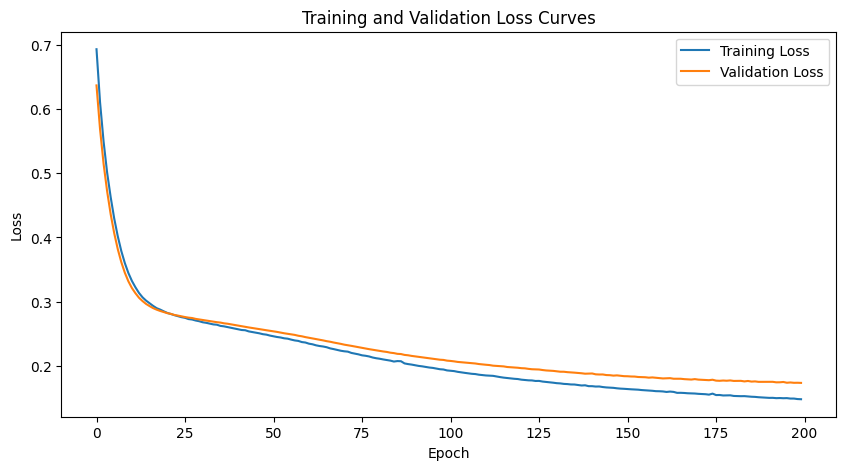


Final Validation Accuracy: 94.00%


In [60]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torch.utils.data import random_split, DataLoader, TensorDataset
from torch.optim import optimizer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

set_seed(42)

# 사용할 데이터셋 설정
# 1. 데이터 생성
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

# 2. PyTorch 텐서로 변환하여 Dataset 생성
dataset = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))

# 3. 7:3 비율로 분할 (700, 300)
train_size = 700
val_size = 300
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 4. DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Total: {len(dataset)}, Train: {len(train_dataset)}, Val: {len(val_dataset)}")
# 결과: Total: 1000, Train: 700, Val: 300

#모델 정의
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MLP(input_size=2, hidden_size=32, output_size=2)


#loss 함수 설정
criterion = nn.CrossEntropyLoss()

#최적화 함수 설정
optimizer = optim.Adam(model.parameters(), lr=0.001)

#결과를 저장할 리스트
train_losses = []
val_losses = []

#학습 및 validation
num_epochs = 200
for epoch in range(num_epochs):
  #학습
  model.train()
  running_loss = 0.0
  for batch_data, batch_labels in train_loader:
    # 1. Forward pass
    outputs = model(batch_data)
    # 2. loss 계산
    loss = criterion(outputs, batch_labels)
    # 3. zero gradients
    optimizer.zero_grad()
    # 4. backward pass
    loss.backward()
    # 5. weight update
    optimizer.step()

    running_loss += loss.item() * batch_data.size(0)

  epoch_train_loss = running_loss / len(train_loader.dataset)
  train_losses.append(epoch_train_loss)

  #validation - 매 epoch마다 검사함
  model.eval()
  val_running_loss = 0.0
  with torch.no_grad():
      for val_data, val_labels in val_loader:
          val_outputs = model(val_data)
          val_loss = criterion(val_outputs, val_labels)
          val_running_loss += val_loss.item() * val_data.size(0)

  epoch_val_loss = val_running_loss / len(val_loader.dataset)
  val_losses.append(epoch_val_loss)

  #epoch 20번마다 loss 출력
  if (epoch + 1) % 20 == 0:
      print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

# --- 그래프 그리기 ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

# --- 최종 모델 평가 (정확도) ---
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, labels in val_loader:
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1) # 가장 높은 확률을 가진 인덱스 추출
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\nFinal Validation Accuracy: {accuracy:.2f}%")


### B2. Experiment Report

### (a) Activation Function Comparison

Sigmoid 활성화 함수 사용 끝
Tanh 활성화 함수 사용 끝
ReLU 활성화 함수 사용 끝


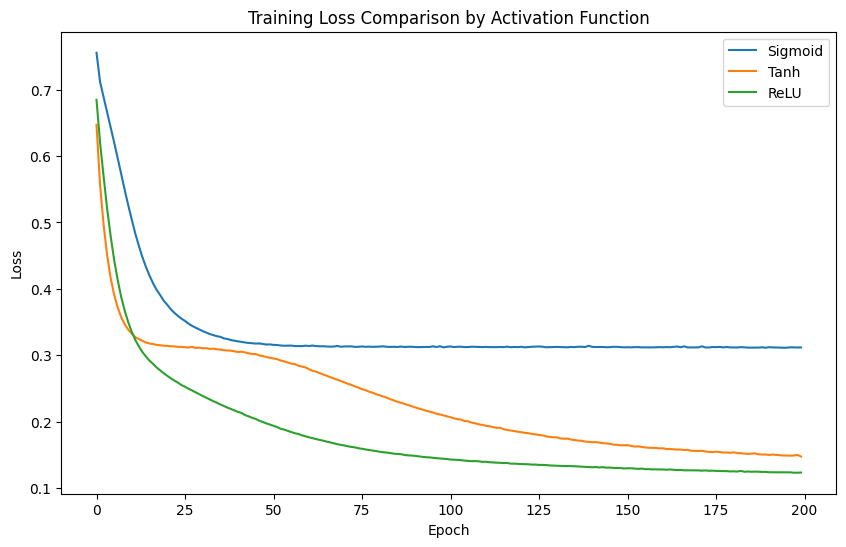

In [61]:
set_seed(42)
activations = {'Sigmoid': nn.Sigmoid(), 'Tanh': nn.Tanh(), 'ReLU': nn.ReLU()}
results = {}

for name, act_func in activations.items():

    class act_func_compriMLP(nn.Module):
        def __init__(self, input_size, hidden_size, output_size):
            super(act_func_compriMLP, self).__init__()
            self.fc1 = nn.Linear(input_size, hidden_size)
            self.fc2 = nn.Linear(hidden_size, output_size)
            self.act = act_func

        def forward(self, x):
            x = self.act(self.fc1(x))
            x = self.fc2(x)
            return x

    model = act_func_compriMLP(input_size=2, hidden_size=32, output_size=2)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_losses = []

    #학습
    num_epochs = 200
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        for batch_data, batch_labels in train_loader:
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_data.size(0)

        train_losses.append(running_loss / len(train_loader.dataset))

    results[name] = train_losses
    print(f"{name} 활성화 함수 사용 끝")

# --- 결과 시각화 ---
plt.figure(figsize=(10, 6))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.title('Training Loss Comparison by Activation Function')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### 분석
그래프를 보면 알 수 있듯이 수렴 속도는 ReLU > Tanh > Sigmoid 순서로 손실 값이 빠르게 줄어든다. 이는 chain rule을 적용하면서 weight 값을 업데이트할 때, 1 이하의 값을 계속 곱하게 되면 gradient의 값이 작아져서 weight 업데이트가 거의 일어나지 않게 되고 결국에는 학습이 거의 이루어지지 않는 기울기 소실 문제를 해결했느냐 아니냐의 차이이다. sigmoid 함수의 미분 값은 최대값이 0.25 이기 때문에 체인 룰을 통해 에러가 뒤로 전달 될 때마다 0.25 이하의 값이 계속 곱해져서 층이 깊어질 수록 앞쪽 층의 weight가 거의 업데이트 되지 않는다. 따라서 그래프 상에서 epoch이 증가하더라도 손실이 줄어들지 않는다.
TanH은 미분 값이 최대 1.0이므로 sigmoid보다는 낫지만, 입력값이 커지거나 작아지면 미분값이 0에 수렴하여 역시 기울기 소실 문제가 발생한다. 그래프 상에서 초반 epoch때 loss가 잠깐 정체된 것이 보인다.
Relu의 경우 양수라면 미분값이 일정하게 1.0으로 유지되므로 에러 신호가 약해지지 않고 그대로 전달되어 그래프 상에서 가장 빠른 수렴속도를 보이며 기울기 소실 문제를 해결한 것으로 보인다.

### (b) Learning Rate Sweep

Learning Rate 0.0001 사용 끝
Learning Rate 0.001 사용 끝
Learning Rate 0.01 사용 끝
Learning Rate 0.1 사용 끝
Learning Rate 1.0 사용 끝


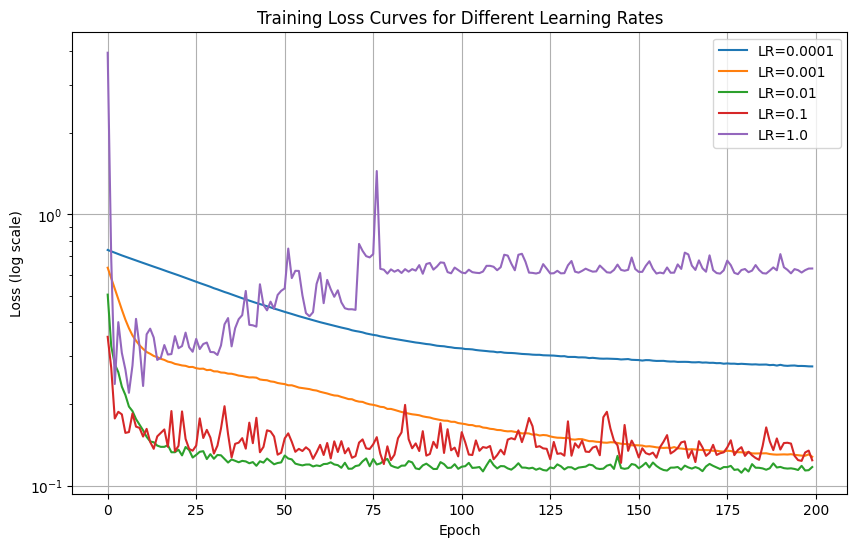

In [62]:
set_seed(42)
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
lr_results = {}

for lr in learning_rates:

    # B1의 ReLU 모델 사용
    model = MLP(input_size=2, hidden_size=32, output_size=2)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    current_lr_losses = []

    for epoch in range(200):
        model.train()
        running_loss = 0.0
        for batch_data, batch_labels in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        current_lr_losses.append(running_loss / len(train_loader))

    lr_results[lr] = current_lr_losses
    print(f"Learning Rate {lr} 사용 끝")

# --- 결과 시각화 ---
plt.figure(figsize=(10, 6))
for lr, losses in lr_results.items():
    plt.plot(losses, label=f'LR={lr}')
plt.yscale('log') # Loss 차이가 커서 로그 적용
plt.title('Training Loss Curves for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.grid(True)
plt.show()

#### 분석
Too Small : 0.0001 <br>
loss가 줄어들긴 하지만 매우 느리게 감소한다. gradient descent 방법으로 weight를 업데이트할 때 업데이트 보폭이 너무 작아 최적의 손실값에 도달하기까지 많은 epoch가 소요된다.
<br> <br>
Appropriate: 0.001, 0.01 <br>
loss 곡선이 매끄럽게 하강하며 안정적으로 minimum point에 도달한다. 학습 초기에 loss 값이 빠르게 감소하며 특히 학습률이 0.01일 때 가장 낮고 안정적으로 minimum point에 도달한다. weight 업데이트 보폭이 적절하여 효율적으로 최저점을 찾아간다.
<br> <br>
Too Large: 0.1, 1.0
loss 값이 매우 불규칙하게 진동하거나 높은 지점에서 정체된다. 특히 학습률이 1.0일 때 초기에는 급격하게 loss값이 증가하는 듯 보이나, 다시 튀어올라 불안정하다. 이는 학습률이 너무 커서 최저점을 지나버렸기 때문이다.
<br> <br>
w' = w -η∇L에서 η값이 너무 클 경우 그래프에서 볼 수 있다 싶이 loss 함수의 최저점을 지나치게 된다. 이때문에 최적의 loss값으로 수렴하지 못하고 최저점 주위를 진동하거나 심한 경우 경사면을 따라 위로 튀어 올라 손실값이 무한히 커져 발산한다.

### (c) Depth vs. Width

#### 파라미터 개수 계산
1. Shallow & Wide: 1 hidden layer with 128 units <br>
Layer 1: (2 * 128) + 128 = 384 <br>
Layer 2: (128 * 2) + 2 = 258 <br>
Total = 384 + 258 = 642 <br>

2. Deep & Narrow: 4 hidden layers with 16 units each <br>
Layer 1: (2 * 16) + 16 = 48 <br>
Layer 2 ~ 4: 3 * ((16 * 16) + 16) = 3 * 272 = 816 <br>
Layer 5: (16*2) + 2 = 34 <br>
Total: 48 + 816 + 34 = 898


(i) Shallow Model Total Parameters: 642
(i) Deep Model Total Parameters: 898


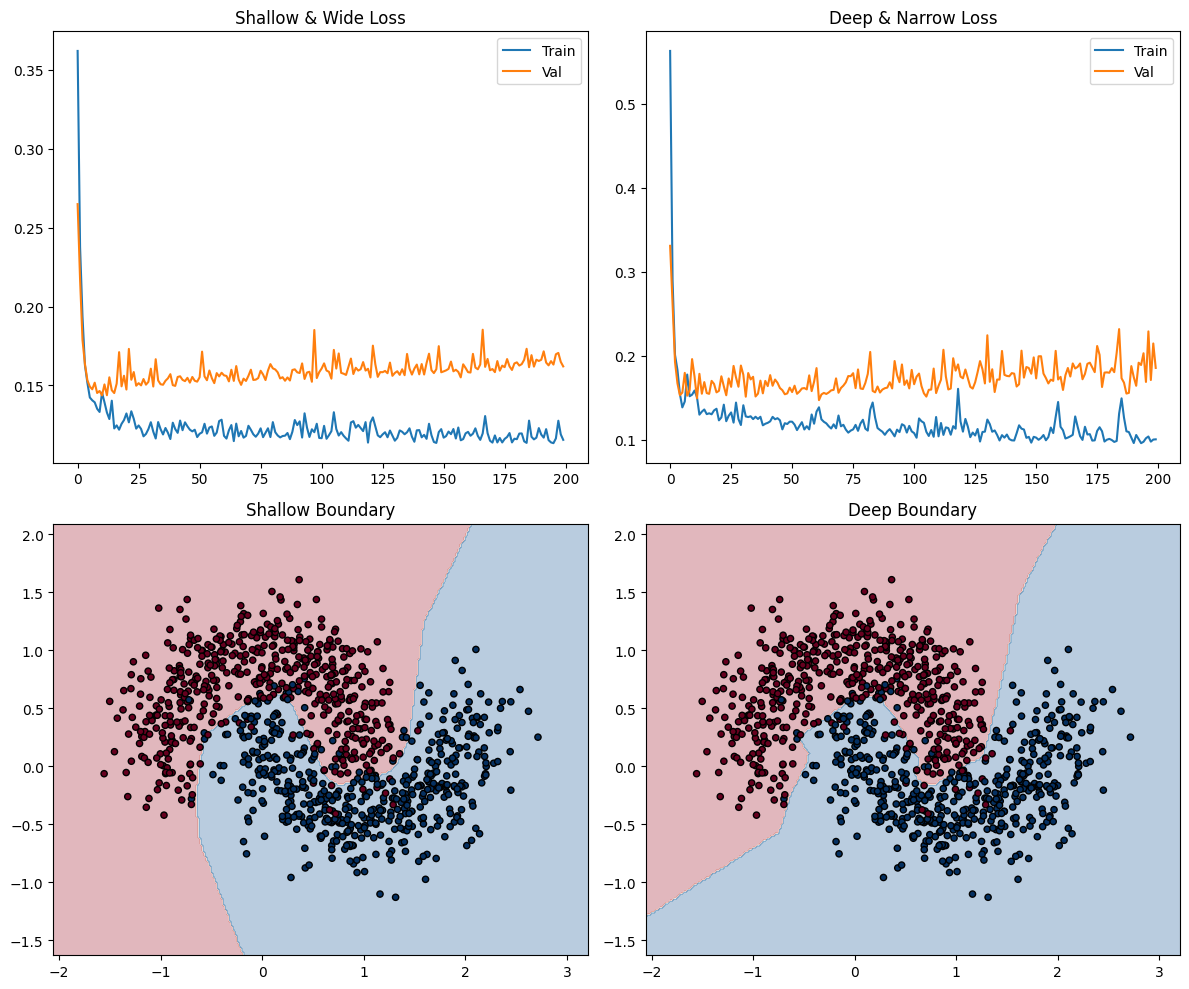

In [63]:
set_seed(42)
# 1. Shallow & Wide 모델 정의 (1 Hidden Layer, 128 Units)
class ShallowWideMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ShallowWideMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x

# 2. Deep & Narrow 모델 정의 (4 Hidden Layers, 16 Units each)
class DeepNarrowMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DeepNarrowMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, hidden_size)
        self.fc5 = nn.Linear(hidden_size, output_size)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        x = self.act(self.fc4(x))
        x = self.fc5(x)
        return x

# 3. 공통 학습 함수
def train_experiment(model, train_loader, val_loader, lr=0.01, epochs=200):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_x.size(0)
        history['train_loss'].append(train_loss / len(train_loader.dataset))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for vx, vy in val_loader:
                vo = model(vx)
                val_loss += criterion(vo, vy).item() * vx.size(0)
        history['val_loss'].append(val_loss / len(val_loader.dataset))
    return history

# 모델 생성
shallow_model = ShallowWideMLP(input_size=2, hidden_size=128, output_size=2)
deep_model = DeepNarrowMLP(input_size=2, hidden_size=16, output_size=2)

print(f"(i) Shallow Model Total Parameters: {sum(p.numel() for p in shallow_model.parameters())}")
print(f"(i) Deep Model Total Parameters: {sum(p.numel() for p in deep_model.parameters())}")

# 학습 진행
shallow_history = train_experiment(shallow_model, train_loader, val_loader)
deep_history = train_experiment(deep_model, train_loader, val_loader)

# 5. 시각화 (Loss Curves & Decision Boundary)
plt.figure(figsize=(12, 10))

# (ii) Loss Curves
plt.subplot(2, 2, 1)
plt.plot(shallow_history['train_loss'], label='Train')
plt.plot(shallow_history['val_loss'], label='Val')
plt.title('Shallow & Wide Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(deep_history['train_loss'], label='Train')
plt.plot(deep_history['val_loss'], label='Val')
plt.title('Deep & Narrow Loss')
plt.legend()

# (iii) Decision Boundaries
plt.subplot(2, 2, 3)
plot_decision_boundary(shallow_model, X, y, "Shallow Boundary")

plt.subplot(2, 2, 4)
plot_decision_boundary(deep_model, X, y, "Deep Boundary")

plt.tight_layout()
plt.show()

#### 분석
그래프 상으로 두 모델의 validation accuracy는 거의 비슷하다. 이론적으로 deep & narrow 모델은 각 층을 거치면서 Hierarchical feature extraction을 더 많이 수행한다. 즉 모델은 각 계층마다 feature를 추출하는데 계층이 늘어날 수록 더 복잡한 feature를 추출한다. 사람의 얼굴로 예를 들자면 처음에는 점, 선만 추출하다가 층이 깊어질 수록 눈, 코, 입 등을 추출하는 것이다. 깊은 모델일 수록 이러한 feature 추출로 복잡한 데이터를 효율적으로 학습한다. validation accuracy는 유사하지만 decision boundary에서는 차이를 보인다. shallow & wide 모델의 경우 가장자리의 경계면이 직선이 가깝게 형성되었지만 deep & narrow 모델의 경우 가장자리 경계면이 완만하게 형성되었다. 이를 통해 deep 모델일 수록 앞서 언급한 hierarchical feature extraction으로 인해 분류를 더 잘 한다는 것을 알 수 있다. deep model의 loss curve 곡선에서 epoch가 증가할 수록 loss가 미묘하게 증가하는 것이 보이는데, 층이 깊어질 수록 기울기 소실 문제가 발생할 가능성이 있기 때문이다. 이번 모델의 경우 4개의 은닉층으로 그렇게 깊지 않아서 학습에 어려움이 유의미할 정도로 나타나진 않았지만 층이 많이 깊어지거나 활성화 함수를 ReLu대신 sigmoid를 사용했다면 기울기 소실 문제가 발생했을 수도 있다.

---
## Part C. Exploring Overfitting

#### C1. Reproducing Overfitting

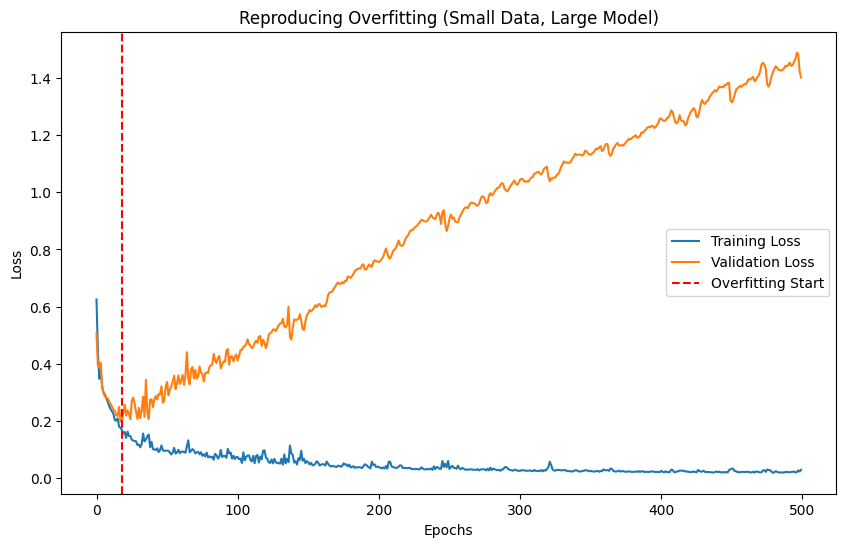

In [69]:
# 1. 작은 데이터셋 생성 (n_samples=100)
X_small, y_small = make_moons(n_samples=100, noise=0.25, random_state=42)
dataset_small = TensorDataset(torch.FloatTensor(X_small), torch.LongTensor(y_small))

# 70/30 분할
train_dataset_small, val_dataset_small = random_split(dataset_small, [70, 30])
train_loader_small = DataLoader(train_dataset_small, batch_size=16, shuffle=True)
val_loader_small = DataLoader(val_dataset_small, batch_size=16, shuffle=False)

# 2. 복잡한 모델 정의 (3 Hidden Layers, 256 Units each)
class LargeMLP(nn.Module):
    def __init__(self):
        super(LargeMLP, self).__init__()
        self.fc1 = nn.Linear(2, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 256)
        self.fc4 = nn.Linear(256, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        return self.fc4(x)

# 3. 학습 설정 (500 Epochs)
model_large = LargeMLP()
optimizer = optim.Adam(model_large.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

for epoch in range(500):
    model_large.train()
    running_loss = 0.0
    for data, labels in train_loader_small:
        optimizer.zero_grad()
        loss = criterion(model_large(data), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
    train_losses.append(running_loss / 70)

    model_large.eval()
    v_loss = 0.0
    with torch.no_grad():
        for vd, vl in val_loader_small:
            v_loss += criterion(model_large(vd), vl).item() * vd.size(0)
    val_losses.append(v_loss / 30)

# 4. 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(x=np.argmin(val_losses), color='r', linestyle='--', label='Overfitting Start') # 최저점 표시
plt.title('Reproducing Overfitting (Small Data, Large Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### 분석
그래프 상에서 epoch가 50이 되기 전에 과적합이 일어난다. Generalization Gap이란 학습 데이터에 대한 일반화 정도와 검증 데이터에 대한 일반화 정도의 차이를 의미한다고 생각한다. 그러니까 두 데이터의 loss 사이의 간격으로 볼 수 있다. 모델은 학습데이터를 반복적으로 학습하기에 학습 데이터에만 최적화된다. 따라서 처음 보는 데이터를 만났을 때는 적절한 성능을 보이지 못한다. 이를 모델이 일반화하지 못했다고 한다. 그래프 상에서 epoch이 진행될 수록 학습 데이터와 검증 데이터에 대한 loss 값의 차이가 벌어진다. 특히 이번 모델의 경우 데이터 셋의 크기가 작기에 이러한 일반화 갭이 심하게 나타난다.모델이 학습을 하는게 아니라 데이터 셋을 아예 통째로 외워버릴 수 있기 때문이다

#### C2. Model Complexity vs. Overfitting

Training Small model...
Training Medium model...
Training Large model...


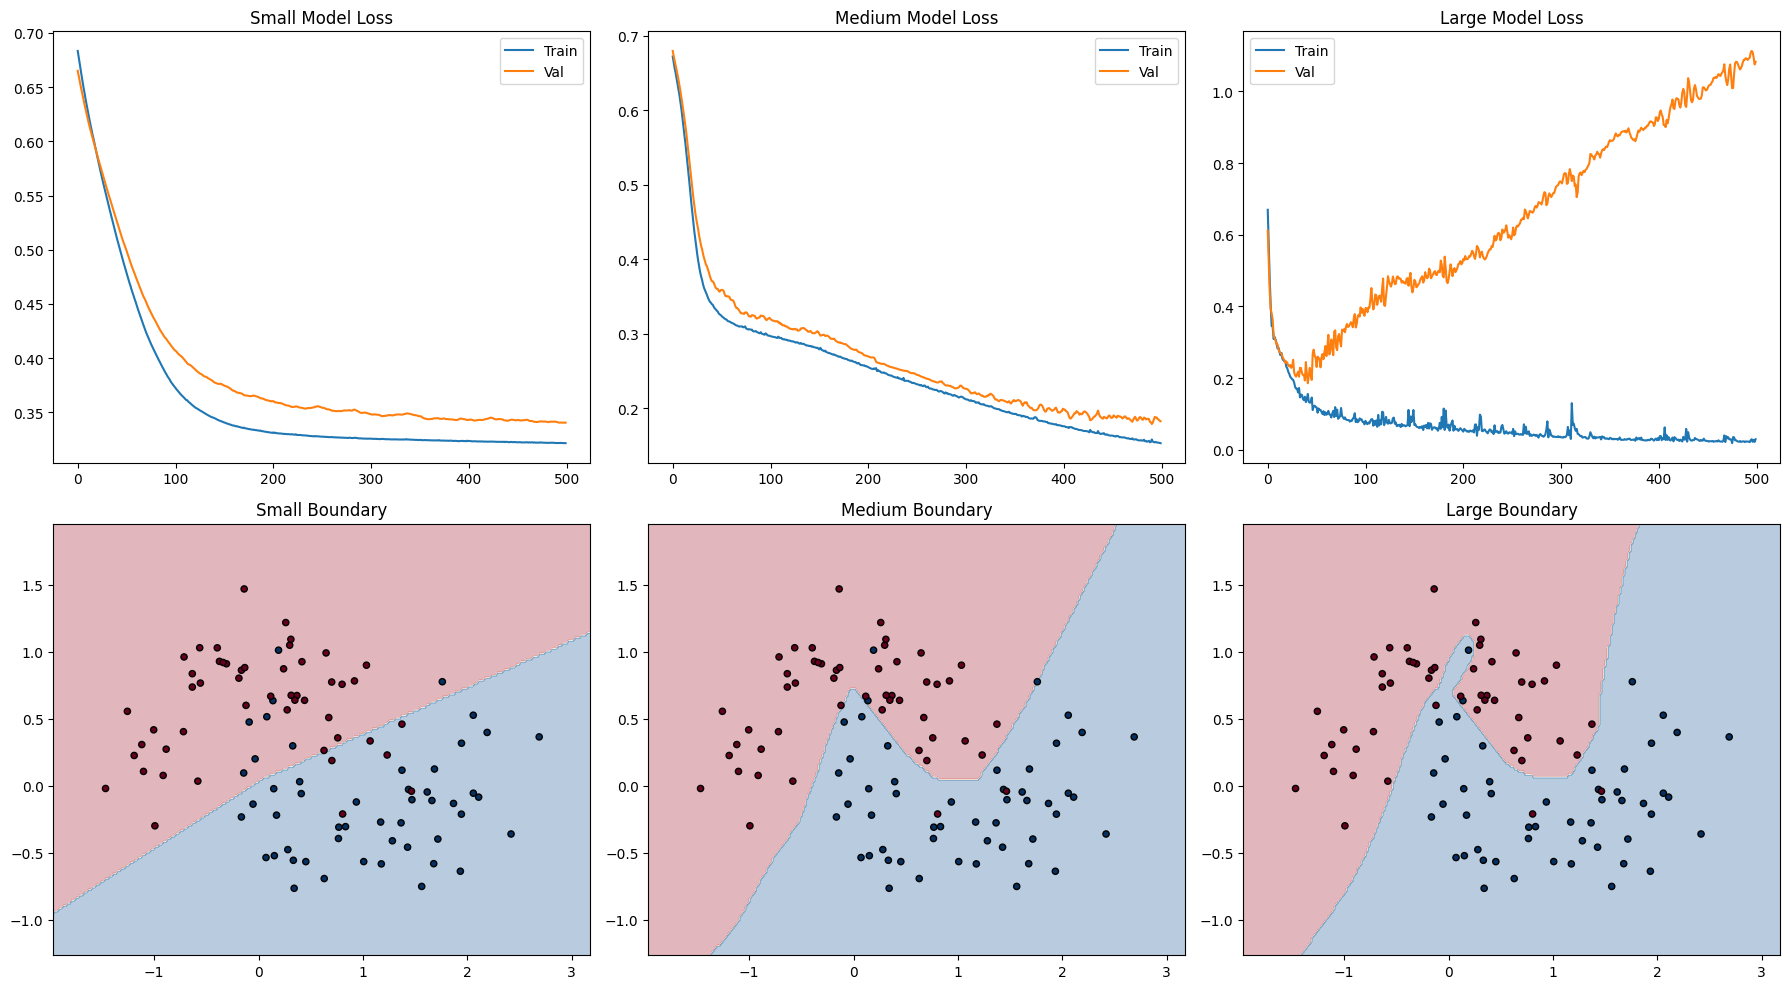

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
# 1. 모델 정의

# Small: 1 hidden layer, 4 units
class SmallMLP(nn.Module):
    def __init__(self):
        super(SmallMLP, self).__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x

# Medium: 2 hidden layers, 16 units each
class MediumMLP(nn.Module):
    def __init__(self):
        super(MediumMLP, self).__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return x

# Large: 3 hidden layers, 128 units each
class LargeMLP(nn.Module):
    def __init__(self):
        super(LargeMLP, self).__init__()
        self.fc1 = nn.Linear(2, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        x = self.fc4(x)
        return x

models = {'Small': SmallMLP(), 'Medium': MediumMLP(), 'Large': LargeMLP()}
results = {}

# C1과 동일한 학습
set_seed(42)
for name, model in models.items():
    print(f"Training {name} model...")
    # 동일한 설정(lr=0.001, epochs=500)으로 학습
    history = train_experiment(model, train_loader_small, val_loader_small, lr=0.001, epochs=500)
    results[name] = {'history': history, 'model': model}

# 3. 결과 출력 (Loss 곡선 및 결정 경계)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, res) in enumerate(results.items()):
    # 상단: Loss Curves
    axes[0, i].plot(res['history']['train_loss'], label='Train')
    axes[0, i].plot(res['history']['val_loss'], label='Val')
    axes[0, i].set_title(f"{name} Model Loss")
    axes[0, i].legend()

    # 하단: Decision Boundaries
    plt.sca(axes[1, i])
    plot_decision_boundary(res['model'], X_small, y_small, f"{name} Boundary")

plt.tight_layout()
plt.show()

#### 분석
small model <br>
작은 모델의 loss curve를 봤을 때 epoch이 증가함에 따라 학습 데이터와 검증 데이터에 대한 loss가 어느순간에 일정하게 높은 loss 값으로 유지된다. 이는 강의자료 5장의 21페이지에서 교수님이 설명해주신 그래프와 동일한 양상을 띈다. decision boundary shapes에게 데이터를 분류하는 경계면이 직선에 가까워 효과적인 분류를 하지 못하고 있다. 따라서 underfitting이라고 생각한다. 모델이 너무 단순하여 학습 데이터와 검증 데이터에 대해 둘다 loss값이 높다. 모델 자체가 제대로 작동하지 못한다. 파라미터를 늘리는 것이 좋다 <br> <br>

medium model <br>
loss curve를 봤을 때 세 가지 모델 중에서 가장 낮은 loss값을 보인다. epoch 200 전까지는 학습 데이터와 검증 데이터 모두 loss 값이 빠르게 증가한다. 또한 decision boundary shapes의 경계면이 적절히 곡선으로 그려져 데이터를 효과적으로 분류한다. 따라서 good fitting으로 볼 수 있다. 그러나 epoch이 200 이후에는 학습이 진행됨에 따라 검증 데이터에 대한 loss값이 늘어나므로 과적합이 일어나고 있음을 알 수 있다 <br><br>

large model <br>
loss curve를 봤을 때 epoch이 50이 되기도 전에 검증 데이터의 loss값이 급격히 증가하면서 과적합이 일어난다. 강의자료 5장의 21페이지 그래프와 똑같은 양상을 보인다. 학습 데이터에 대해서는 꾸준히 낮은 loss를 보이지만 검증 데이터에 대해서는 학습이 진행될 수록 loss값이 증가하는 전형적인 과적합 모델이다. 또한 decision boundary shapes의 경계면에서 파란색 부분이 빨간색 부분 안쪽까지 깊숙히 침투하도록 경계면이 그려졌다. 이는 모델이 noise도 학습했다는 것을 의미한다. generalization gap이 발생한 것이다. 따라서 모델을 좀 더 단순하게 만들거나 과적합이 일어나기 전에 멈추는 것이 좋다

#### C3. Dataset Size vs. Overfitting

Training Large model with n_samples = 100...
Training Large model with n_samples = 500...
Training Large model with n_samples = 2000...
Training Large model with n_samples = 5000...


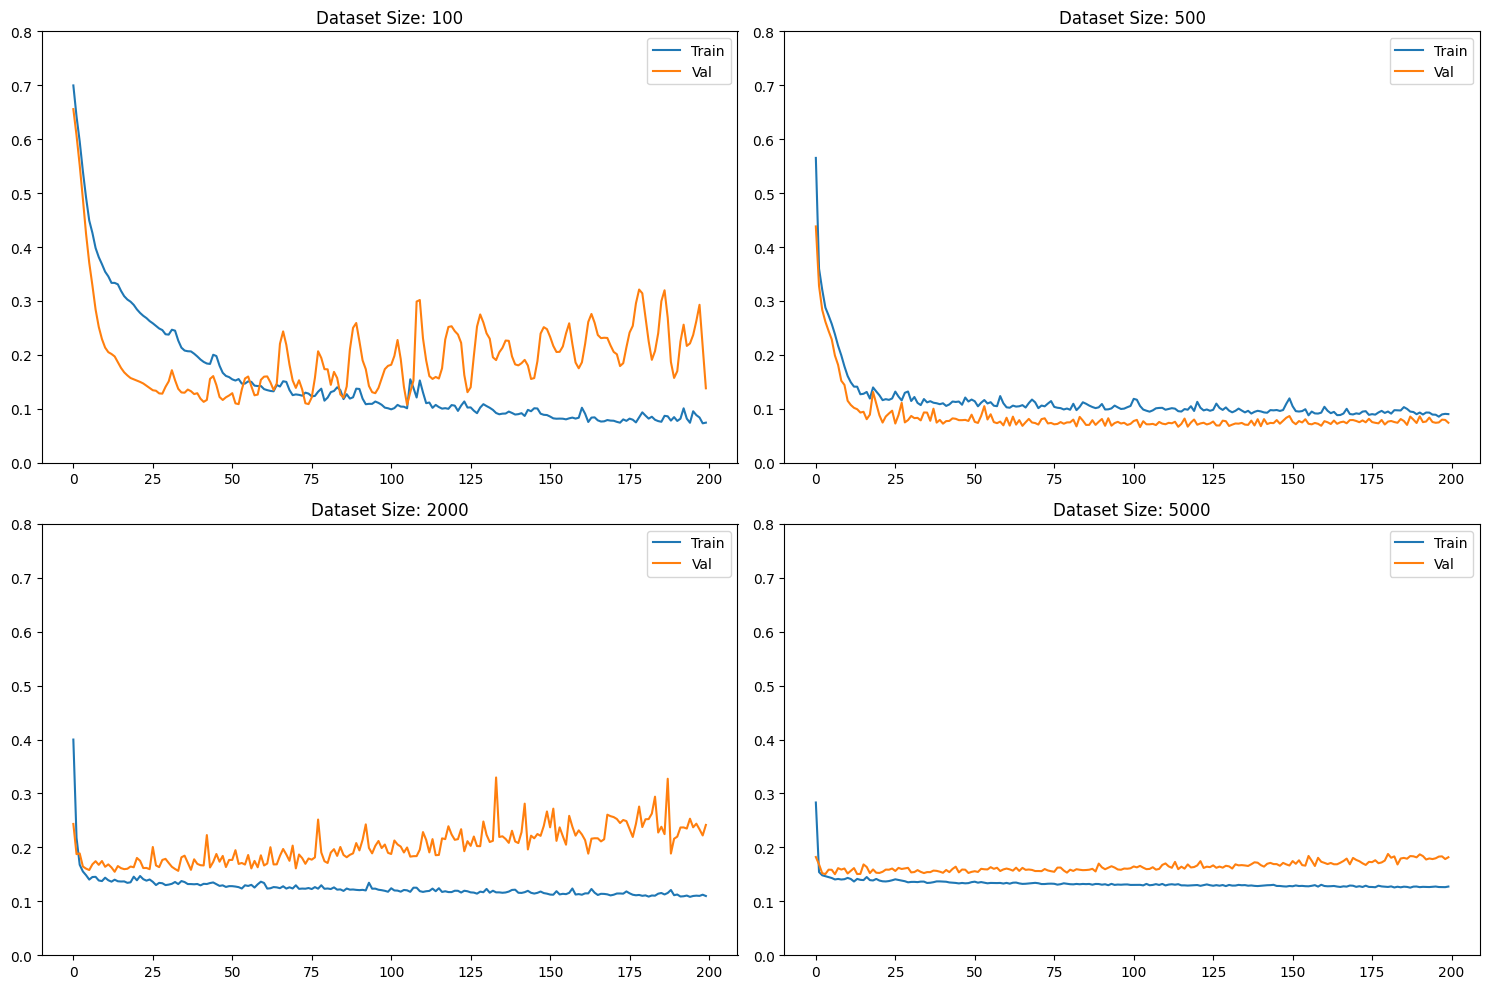

In [72]:
# C2의 LargeMLP 구조를 고정
data_sizes = [100, 500, 2000, 5000]
c3_results = {}
set_seed(42)
for n in data_sizes:
    print(f"Training Large model with n_samples = {n}...")

    # 1. 각 사이즈에 맞는 데이터 생성 및 분할
    X_n, y_n = make_moons(n_samples=n, noise=0.25, random_state=42)
    dataset_n = TensorDataset(torch.FloatTensor(X_n), torch.LongTensor(y_n))

    train_size = int(0.7 * n)
    val_size = n - train_size
    train_ds, val_ds = random_split(dataset_n, [train_size, val_size])

    t_loader = DataLoader(train_ds, batch_size=min(32, train_size), shuffle=True)
    v_loader = DataLoader(val_ds, batch_size=min(32, val_size), shuffle=False)

    # 2. 모델 초기화 및 학습 (동일 조건)
    model_c3 = LargeMLP()
    history = train_experiment(model_c3, t_loader, v_loader, lr=0.001, epochs=200)
    c3_results[n] = history

# 3. 결과 시각화
plt.figure(figsize=(15, 10))
for i, n in enumerate(data_sizes):
    plt.subplot(2, 2, i+1)
    plt.plot(c3_results[n]['train_loss'], label='Train')
    plt.plot(c3_results[n]['val_loss'], label='Val')
    plt.title(f"Dataset Size: {n}")
    plt.ylim(0, 0.8) # 비교를 위해 y축 고정
    plt.legend()

plt.tight_layout()
plt.show()

#### 분석
1. n = 100 <br>
학습 데이터에 대한 loss는 낮게 유지되지만 검증 데이터에 대해서는 loss값이 크게 진동하며 높은 값을 유지한다. 두  곡선 사이의 간격인 Generalization Gap이 매우 넓다. 이는 전형적인 과적합 상태이다 <br><br>

2. n = 500, 2000 <br>
검증 데이터에 대한 loss값의 진동이 점차 줄어들고 학습 데이터와의 loss 값 차이, Generalization Gap이 줄어든다. 단 2000 모델에 대해서는 검증 데이터에 대한 loss값이 학습을 진행할 수록 조금씩 늘어나 과적합이 일어난다. <br><br>

3. n = 5000
loss값의 진동이 거의 없다. 학습 데이터와 검증 데이터에 대해 loss값의 차이가 매우 작아진다. 즉 데이터가 충분히 많아지면 Generalization Gap이 최소화되며 모델이 안정화된다.

강의 슬라이드에 등장하는 그래프는 데이터의 양이 늘어날 수록 큰 모델이 기존 모델보다 훨씬 더 높은 성능을 보인다는 걸 나타낸다.
C2의 큰 모델은 데이터가 적을 때는 노이즈까지 외워버려서 일반화를 잘 하지 못했으나 데이터가 5000개까지 늘어나면서 데이터의 실제 패턴을 정교하게 학습해 모델의 성능이 올라갔다. 즉 데이터가 많아질수록 노이즈가 학습에 미치는 영향이 줄어들면서 과적합이 줄어든다. 데이터가 늘어날 수록 모델의 정확도가 증가하는 것이다. 이러한 큰 NN은 많은 파라미터를 가지고 있어 함수를 자유롭게 변형할 수 있다. 이때 많은 양의 데이터는 모델이 제멋대로 복잡해지지 않도록 하는 일종의 제약 역할을 한다. 따라서 모델이 데이터를 외우지 않고 일반화를 하도록 한다.

